In [1]:
import numpy as np
import matplotlib.pyplot as pl
import scipy as sp
import scipy.sparse.linalg
#from numba import jit
from matplotlib import cm

pl.rcParams['mathtext.fontset'] = 'cm'
pl.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
pl.rcParams['font.serif'] = 'cmr10'
pl.rcParams['font.sans-serif'] = 'cmss10'
pl.rcParams['font.monospace'] = 'cmtt10'
pl.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs
pl.rcParams['font.size'] = 22

In [2]:
g = -1

#@jit
def V(x,v1,v2,M,N,phi):
    return v1*np.cos(2*x)+v2*np.cos(2*M/N*x+phi)

#@jit
def GPE1D(psi,mu,hx,nx,pot):

    gradient = np.zeros(nx)
    gradient[1:-1] = -1/(2*hx**2)*(psi[:-2]-2*psi[1:-1]+psi[2:])
    gradient[0] = -1/(2*hx**2)*(psi[-1]-2*psi[0]+psi[1])
    gradient[-1] = -1/(2*hx**2)*(psi[-2]-2*psi[-1]+psi[0])
    function = gradient - mu*psi + g*psi**3 + pot*psi
    return function

#@jit
def espetro(nx,M,N,v1,v2,phi,niveis):
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]
    
    potential = V(xx[:-1],v1,v2,M,N,phi)
    
    diagonal1 = -1/(2*hx**2)*np.ones(nx-1)
    diagonal = potential+1/hx**2
    fronteira = -1/(2*hx**2)
    diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira]
        
    J = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr') 
    
    values, vectors = scipy.sparse.linalg.eigs(J,niveis,which='SM')
    
    return xx[:-1],values,vectors,phi

#@jit
def newtonquasi(nx,M,N,v1,v2,phi,eps,mu,psi):
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]

    potential = V(xx[:-1],v1,v2,M,N,phi)
    dpsi = np.ones(nx)
    
    diagonal1 = -1/(2*hx**2)*np.ones(nx-1)
    fronteira = -1/(2*hx**2)
    
    while abs(np.linalg.norm(dpsi)) > eps:
        diagonal = -mu+potential+3*g*psi**2+1/hx**2
        diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira]
        
        J = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr')
        
        dpsi = sp.sparse.linalg.spsolve(J,-GPE1D(psi,mu,hx,nx,potential))
        psi += dpsi
         
    return xx[:-1],psi,potential 

#@jit
def varrimento(nx,M,N,v1,v2,phi,eps,mu,psi,it):
    
    estados = np.zeros([nx,it])
    potenciais = np.zeros(it)
    
    for i in range(it):
        #if i%100 == 0:
        estados[:,i] = psi
        potenciais[i] = mu
    
        print(i)
        
        mu -= 10**(-6)
        #mu -= 10**(-8)
        #mu += 10**(-4)
        
        xx,onda,potencial = newtonquasi(nx,M,N,v1,v2,phi,eps,mu,psi)
        psi = onda
        
    return estados,potenciais

#@jit
def bdgennes(nx,M,N,v1,v2,phi,psig,mug,niveis):
    
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]
    
    potential = V(xx[:-1],v1,v2,M,N,phi)
    
    diagonal1 = np.zeros(2*nx-1)
    diagonal1[0:nx-1] = -1/(2*hx**2)
    diagonal1[nx:] = 1/(2*hx**2)
    diagonal = np.concatenate((1/hx**2+potential-mug+2*g*psig**2,-1/hx**2-potential+mug-2*g*psig**2))
    
    fronteira = np.zeros(nx+1)
    fronteira[0] = -1/(2*hx**2)
    fronteira[-1] = 1/(2*hx**2)
    
    nonlinear = g*psig**2
    nonlinearc = g*psig**2
    diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira,-nonlinear,nonlinearc]
        
    J = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1,nx,-nx),(2*nx,2*nx),'csr') 
    
    values, vectors = scipy.sparse.linalg.eigs(J,niveis,sigma=0)
    #values, vectors = scipy.sparse.linalg.eigs(J,niveis,which='SR')
    
    
    return xx[:-1],values,vectors,phi


def evolucao(t,num,nx,M,N,v1,v2,phi,psi0):
    dt = t/num 
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]
    
    potential = V(xx[:-1],v1,v2,M,N,phi)
    #history = np.zeros([num,nx],dtype=complex)
    
    #modulos = np.zeros(num)
    
    psi = psi0
    
    normalizar0 = psi0.real**2+psi0.imag**2

    const0 = (hx/3) * (normalizar0[0] + 2*sum(normalizar0[:nx-2:2]) + 4*sum(normalizar0[1:nx-1:2]) + normalizar0[nx-1])
    
    diagonalq = 2*(2*hx**2*1j-dt)/dt*np.ones(nx)
    diagonalq1 = np.ones(nx-1)
    fronteira = 1
    diagonalsq = [diagonalq,diagonalq1,diagonalq1,fronteira,fronteira]
    
    
    Q = sp.sparse.diags(diagonalsq,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr')
    
    #for tempo in range(num):
        
        #history[tempo] = psi
    
    diagonal1 = -1*np.ones(nx-1)
    fronteira = -1        
    diagonal = 2*(1+(2*hx**2*1j/dt)+2*hx**2*potential+2*hx**2*g*(psi.real**2+psi.imag**2))
        
    diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira]
        
    H = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr')
        
    vetor = H@psi
        
    psi = sp.sparse.linalg.spsolve(Q,vetor)
        
    normalizar = psi.real**2+psi.imag**2

    const = (hx/3) * (normalizar[0] + 2*sum(normalizar[:nx-2:2]) + 4*sum(normalizar[1:nx-1:2]) + normalizar[nx-1])
    
    psi = psi*np.sqrt(const0/const)
    
    #modulos[tempo] = const
        
        
    return psi,const0


# Time evolution using the Split-step Fourier method
def time_step(t,num,nx,M,N,v1,v2,phi,psi):

    dt = t/num 
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]
    
    potential = V(xx[:-1],v1,v2,M,N,phi)
    
    
    kx = 2 * np.pi * np.fft.fftfreq(nx, hx)  # Fourier space wavenumbers
    k_squared = kx**2  # k^2 for kinetic term

    
    # Step 1: Apply the non-linear term in real space
    psi_nonlinear = np.exp(-1j * (g * (psi.real**2+psi.imag**2)+potential) * dt) * psi
    
    # Step 2: Apply the kinetic and potential terms in Fourier space
    psi_k = np.fft.fft(psi_nonlinear)  # Transform to Fourier space
    psi_k = np.exp(1j * k_squared * dt) * psi_k  # Kinetic evolution
    #psi_k = np.fft.fftshift(psi_k)  # Shift to center (important for periodicity)
    
    psi_k = np.fft.ifft(psi_k)  # Transform back to real space
    
    return psi_k

import numpy as np
from scipy.fft import fft, ifft

def time_step2(t, num_steps, nx, M, N, v1, v2, phi, psi):
    dt = t / num_steps
    
    # Spatial grid (periodic, excluding endpoint)
    xx = np.linspace(-np.pi*N/2, np.pi*N/2, nx, endpoint=False)
    dx = xx[1] - xx[0]
    
    potential = V(xx, v1, v2, M, N, phi)
    
    # Fourier space setup
    kx = 2 * np.pi * np.fft.fftfreq(nx, dx)
    k_squared = kx**2
    
    # Pre-compute evolution operators
    exp_K_half = np.exp(-0.5j * k_squared * dt)  # Half kinetic step
    exp_V = np.exp(-1j * dt * potential)  # Potential part
    
    #for _ in range(num_steps):
        # Split-step Fourier method (symmetric)
        
        # 1. Half kinetic step in Fourier space
    psi = ifft(exp_K_half * fft(psi))
        
        # 2. Full potential + nonlinear step in real space
    psi = exp_V * np.exp(-1j * dt * g * np.abs(psi)**2) * psi
        
        # 3. Half kinetic step in Fourier space
    psi = ifft(np.fft.fftshift(exp_K_half * fft(psi)))
        
        # Optional: Renormalize to preserve particle number
        # norm = np.sqrt(np.sum(np.abs(psi)**2) * dx)
        # psi /= norm
    
    return psi

In [3]:
nx = 5000
M = 233
N = 144
v1 = 0.8
v2 = 0.1
fase = -np.sqrt(2)

In [4]:
#g=-1 e delta mu -10**-6


xx,vlinear3,psilinear3,phi = espetro(nx,M,N,v1,v2,fase,300)
hx = xx[1]-xx[0]
    
#indice = np.argmin(vlinear3)
indice = np.ravel(np.where(vlinear3 == sorted(vlinear3)[89]))[0]
    
mu = vlinear3[indice].real
psi = psilinear3[:,indice]

normalizar = psilinear3[:,indice]**2

const = (hx/3) * (normalizar[0] + 2*sum(normalizar[:nx-2:2]) + 4*sum(normalizar[1:nx-1:2]) + normalizar[nx-1])

estados3,potenciais3 = varrimento(nx,M,N,v1,v2,fase,10**(-6),mu,psi/np.sqrt(const),3000)

/tmp/ipykernel_18137/2684521593.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  estados[:,i] = psi
/tmp/ipykernel_18137/2684521593.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  gradient[1:-1] = -1/(2*hx**2)*(psi[:-2]-2*psi[1:-1]+psi[2:])
/tmp/ipykernel_18137/2684521593.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  gradient[0] = -1/(2*hx**2)*(psi[-1]-2*psi[0]+psi[1])
/tmp/ipykernel_18137/2684521593.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  gradient[-1] = -1/(2*hx**2)*(psi[-2]-2*psi[-1]+psi[0])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1861
1862
1863
1864
1865
1866
1867
1868
1869
1870
1871
1872
1873
1874
1875
1876
1877
1878
1879
1880
1881
1882
1883
1884
1885
1886
1887
1888
1889
1890
1891
1892
1893
1894
1895
1896
1897
1898
1899
1900
1901
1902
1903
1904
1905
1906
1907
1908
1909
1910
1911
1912
1913
1914
1915
1916
1917
1918
1919
1920
1921
1922
1923
1924
1925
1926
1927
1928
1929
1930
1931
1932
1933
1934
1935
1936
1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060


In [6]:
nbdg = 500

xx,valuesa,vectorsa,phi = bdgennes(nx,M,N,v1,v2,fase,estados3[:,2000],potenciais3[2000],nbdg)

print(max(valuesa.imag))

participacao = np.zeros(nbdg)
norm = np.zeros(nbdg)

participacaou = np.zeros(nbdg)
normu = np.zeros(nbdg)
participacaov = np.zeros(nbdg)
normv = np.zeros(nbdg)


hx = xx[1]-xx[0]
ht = xx[1]-xx[0]

for n,m in enumerate(sorted(valuesa.real)):
    nivel = np.ravel(np.where(valuesa.real==(m)))
    
    u = vectorsa[0:nx,nivel[0]]
    v = vectorsa[nx:,nivel[0]]
    
    u2 = u.real**2+u.imag**2
    v2 = v.real**2+v.imag**2
    
    onda = u - v
    
    psi = (onda.real**2+onda.imag**2)
    
    natomsu = (ht/3) * (u2[0] + 2*sum(u2[:nx-2:2]) + 4*sum(u2[1:nx-1:2]) + u2[nx-1])
    natomsv = (ht/3) * (v2[0] + 2*sum(v2[:nx-2:2]) + 4*sum(v2[1:nx-1:2]) + v2[nx-1])
    
    iprsu = (u.real**4+2*u.real**2*u.imag**2+u.imag**4)
    iprsv = (v.real**4+2*v.real**2*v.imag**2+v.imag**4)
    
    ipru = (1/natomsu**2)*(ht/3)*(iprsu[0] + 2*sum(iprsu[:nx-2:2]) + 4*sum(iprsu[1:nx-1:2]) + iprsu[nx-1])
    iprv = (1/natomsv**2)*(ht/3)*(iprsv[0] + 2*sum(iprsv[:nx-2:2]) + 4*sum(iprsv[1:nx-1:2]) + iprsv[nx-1])
    
    
    natoms = (ht/3) * (psi[0] + 2*sum(psi[:nx-2:2]) + 4*sum(psi[1:nx-1:2]) + psi[nx-1])
    
    iprs = (onda.real**4+2*onda.real**2*onda.imag**2+onda.imag**4)
    
    ipr = (1/natoms**2)*(ht/3)*(iprs[0] + 2*sum(iprs[:nx-2:2]) + 4*sum(iprs[1:nx-1:2]) + iprs[nx-1])
    
    participacao[n] = ipr
    norm[n] = natoms
    

    participacaou[n] = ipru
    normu[n] = natomsu
    participacaov[n] = iprv
    normv[n] = natomsv

2.211959763209303e-05


In [10]:
ondabc = estados3[:,0]
psibc = (ondabc.real**2+ondabc.imag**2)
    

natomsbc = (ht/3) * (psibc[0] + 2*sum(psibc[:nx-2:2]) + 4*sum(psibc[1:nx-1:2]) + psibc[nx-1])
    
iprsbc = (ondabc.real**4+2*ondabc.real**2*ondabc.imag**2+ondabc.imag**4)
    
iprbc = (1/natomsbc**2)*(ht/3)*(iprsbc[0] + 2*sum(iprsbc[:nx-2:2]) + 4*sum(iprsbc[1:nx-1:2]) + iprsbc[nx-1])

print(r'$\tilde{\chi_{55}}$=',iprbc)
print(r'$\chi_u$=',participacaou[4856])
print(r'$\chi_v$=',participacaov[4856])

$\tilde{\chi_{55}}$= 0.007262206175159536
$\chi_u$= 0.019623439876731614
$\chi_v$= 0.05237726891518642


<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_18137/1589946718.py:11: SyntaxWarning: invalid escape sequence '\p'
  pl.ylabel('$\psi$')


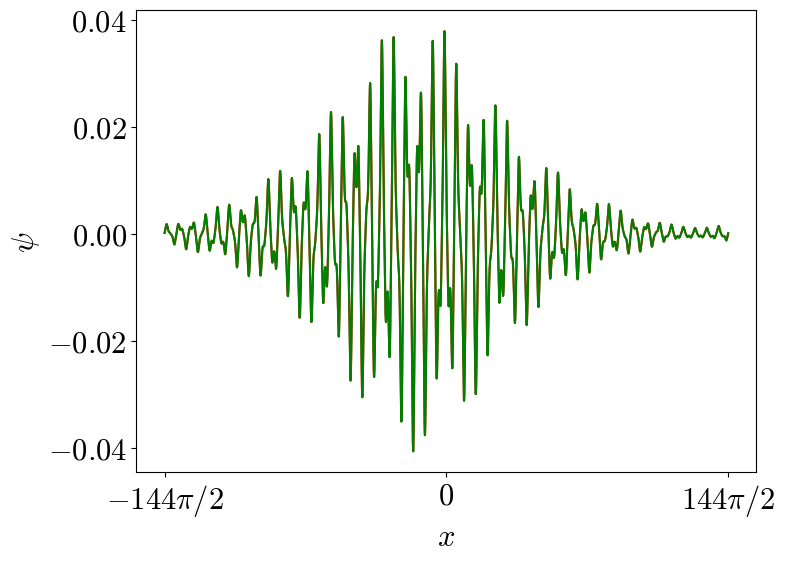

In [13]:
indice = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[250]))[0]

pl.figure(figsize=[8,6])
#pl.xscale('log')
#pl.yscale('log')

barras=(-144*np.pi/2,0,144*np.pi/2)
labels=(r'$-144\pi/2$','0',r'$144\pi/2$')
pl.xticks(barras,labels)
pl.xlabel('$x$')
pl.ylabel('$\psi$')

#pl.plot(xx,-0.5*estados3[:,2000],color='black',linewidth=0.5)

pl.plot(xx,vectorsa[0:nx,indice],color='red')
pl.plot(xx,vectorsa[nx:,indice],color='green')


<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_35331/31558573.py:14: SyntaxWarning: invalid escape sequence '\p'
  subfigs[0].set_ylabel('$\psi$')
/tmp/ipykernel_35331/31558573.py:30: SyntaxWarning: invalid escape sequence '\p'
  subfigs[1].set_ylabel('$\psi$')
/tmp/ipykernel_35331/31558573.py:33: SyntaxWarning: invalid escape sequence '\p'
  subfigs[1].set_ylabel('$\psi$')
/tmp/ipykernel_35331/31558573.py:41: SyntaxWarning: invalid escape sequence '\p'
  subfigs[2].set_ylabel('$\psi$')
/tmp/ipykernel_35331/31558573.

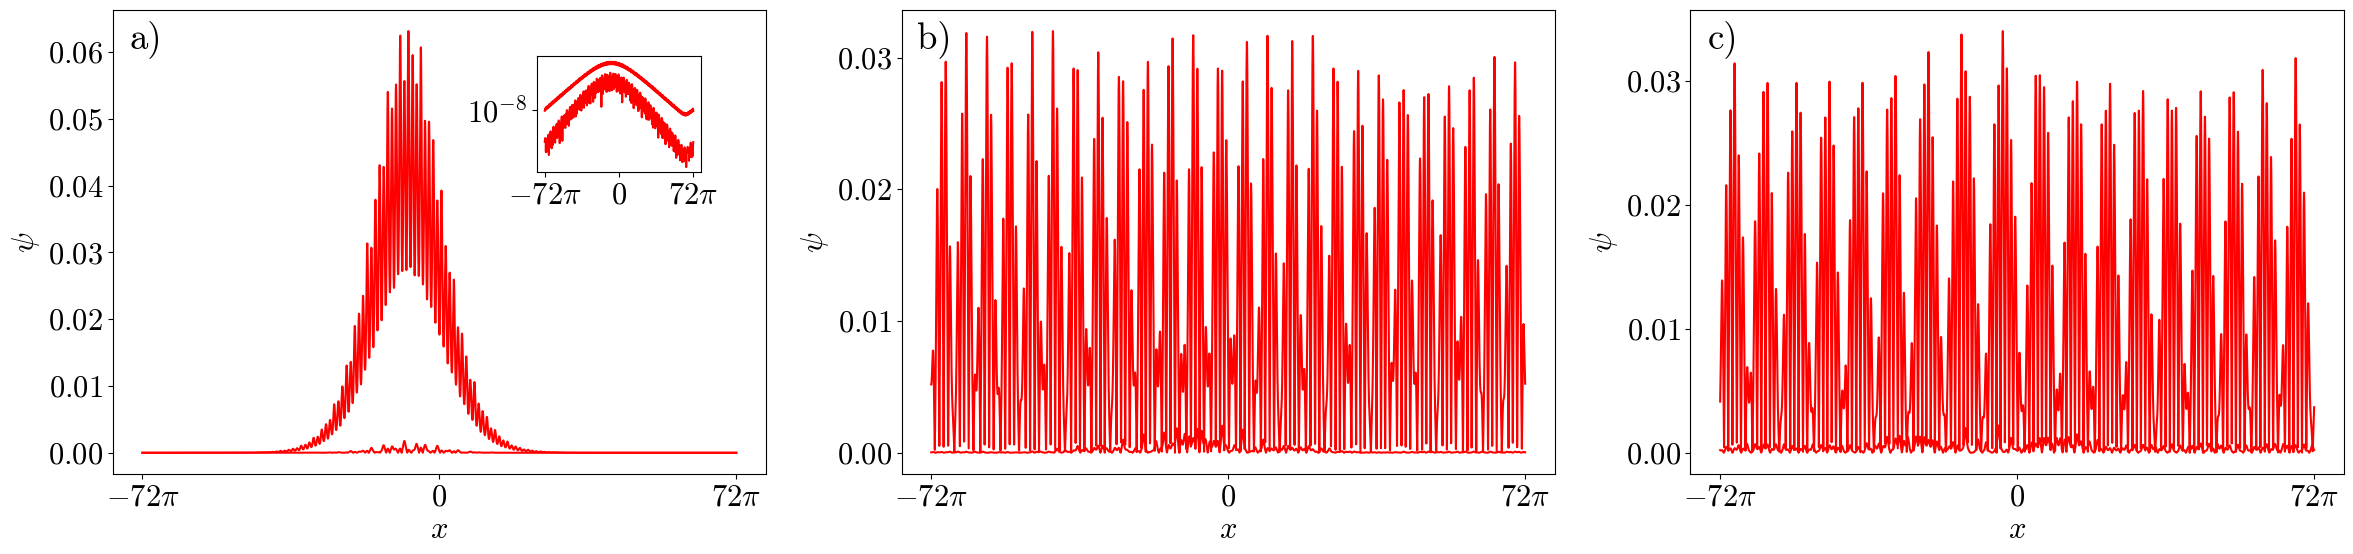

In [7]:
indice1 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4856]))[0]
indice2 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4950]))[0]
indice3 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4937]))[0]
barras=(-72*np.pi,0,72*np.pi)
labels=(r'$-72\pi$','0',r'$72\pi$')

fig = pl.figure(figsize=[24,6])

subfigs = fig.subplots(1,3)

subfigs[0].set_title("a)", x=0.05, y=0.9)
inset = subfigs[0].inset_axes([0.65, 0.65, 0.25, 0.25])
subfigs[0].set_xlabel('$x$')
subfigs[0].set_ylabel('$\psi$')
subfigs[0].set_xticks(barras,labels)

subfigs[0].plot(xx,abs(vectorsa[0:nx,indice1]),color='red')
subfigs[0].plot(xx,abs(vectorsa[nx:,indice1]),color='red')


inset.set_xticks(barras,labels)
inset.set_yscale('log')


inset.plot(xx,abs(vectorsa[0:nx,indice1]),color='red')
inset.plot(xx,abs(vectorsa[nx:,indice1]),color='red')

subfigs[1].set_title("b)", x=0.05, y=0.9)
subfigs[1].set_xlabel('$x$')
subfigs[1].set_ylabel('$\psi$')
subfigs[1].set_xticks(barras,labels)
subfigs[1].set_xlabel('$x$')
subfigs[1].set_ylabel('$\psi$')


subfigs[1].plot(xx,abs(vectorsa[0:nx,indice2]),color='red')
subfigs[1].plot(xx,abs(vectorsa[nx:,indice2]),color='red')

subfigs[2].set_title("c)", x=0.05, y=0.9)
subfigs[2].set_xlabel('$x$')
subfigs[2].set_ylabel('$\psi$')
subfigs[2].set_xticks(barras,labels)
subfigs[2].set_xlabel('$x$')
subfigs[2].set_ylabel('$\psi$')


subfigs[2].plot(xx,abs(vectorsa[0:nx,indice3]),color='red')
subfigs[2].plot(xx,abs(vectorsa[nx:,indice3]),color='red')

pl.tight_layout()
pl.show()

4856
4857
5142
5143


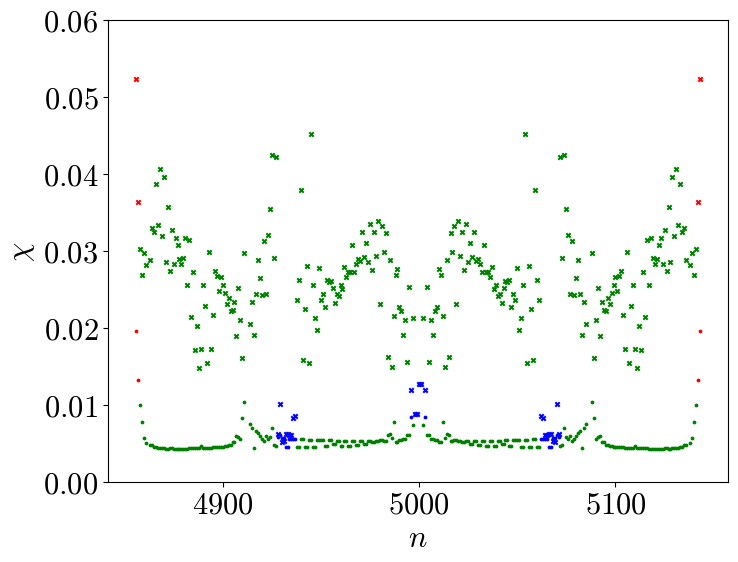

In [28]:
pl.figure(figsize=[8,6])
pl.ylim(0,0.06)

pl.xlabel('$n$')
pl.ylabel(r'$\chi$')

deslocalizados = []
ulocalizado = []
vlocalizado = []
localizados = []

for i in range(4500,5500):
    if participacaou[i] > 0.013:
        if participacaov[i] > 0.013:
            pl.scatter(i,participacaou[i],color='red',s=3)
            pl.scatter(i,participacaov[i],color='red',s=10,marker='x')
            print(i)
            localizados.append(i)
        elif normu[i] > 10**(-6):
            pl.scatter(i,participacaou[i],color='green',s=3)
            pl.scatter(i,participacaov[i],color='green',s=10,marker='x')
            ulocalizado.append(i)
    elif participacaov[i] > 0.013: 
        if normv[i] > 10**(-6):
            pl.scatter(i,participacaou[i],color='green',s=3)
            pl.scatter(i,participacaov[i],color='green',s=10,marker='x')
            vlocalizado.append(i)
    else:
        pl.scatter(i,participacaou[i],color='blue',s=3)
        pl.scatter(i,participacaov[i],color='blue',s=10,marker='x')
        deslocalizados.append(i)

In [14]:
print(ulocalizado)

[4914, 4915, 4917, 4918, 4919, 4922, 4923, 4924, 4925, 4940, 4941, 4944, 4945, 4948, 4949, 4950, 4951, 4954, 4955, 4958, 4959, 4962, 4963, 4966, 4967, 4970, 4971, 4974, 4975, 4978, 4979, 4982, 4983, 4988, 4989, 4990, 4991, 4992, 4993, 4994, 4995, 4997, 5012, 5013, 5014, 5015, 5018, 5019, 5022, 5023, 5026, 5027, 5030, 5031, 5034, 5035, 5038, 5039, 5042, 5043, 5046, 5047, 5052, 5053, 5056, 5057, 5060, 5061, 5072, 5073, 5078, 5079, 5083, 5088, 5089, 5090, 5091, 5092, 5093, 5094, 5095, 5096, 5097, 5098, 5099, 5100, 5101, 5102, 5103, 5104, 5105, 5106, 5107, 5108, 5109, 5110, 5111, 5112, 5113, 5114, 5115, 5116, 5117, 5118, 5119, 5120, 5121, 5122, 5123, 5124, 5125, 5126, 5127, 5128, 5129, 5130, 5131, 5132, 5133, 5134, 5135, 5136, 5138, 5139, 5140, 5141]


/usr/lib/python3/dist-packages/matplotlib/collections.py:193: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


4856
4857
5142
5143


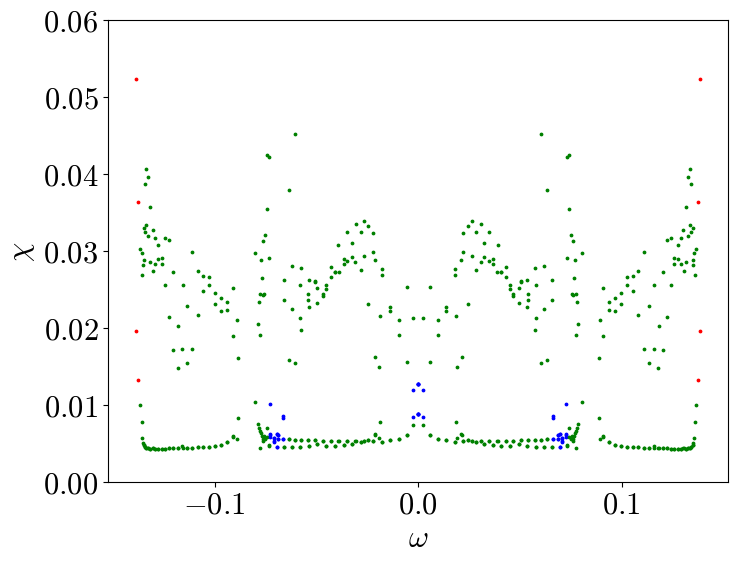

In [10]:
pl.figure(figsize=[8,6])
pl.ylim(0,0.06)

pl.xlabel(r'$\omega$')
pl.ylabel(r'$\chi$')

deslocalizados = []
ulocalizado = []
vlocalizado = []
localizados = []

for i in range(4500,5500):
    if participacaou[i] > 0.013:
        if participacaov[i] > 0.013:
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='red',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='red',s=3)
            print(i)
            localizados.append(i)
        elif normu[i] > 10**(-6):
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='green',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='green',s=3)
            ulocalizado.append(i)
    elif participacaov[i] > 0.013: 
        if normv[i] > 10**(-6):
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='green',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='green',s=3)
            vlocalizado.append(i)
    else:
        pl.scatter(sorted(valuesa)[i],participacaou[i],color='blue',s=3)
        pl.scatter(sorted(valuesa)[i],participacaov[i],color='blue',s=3)
        deslocalizados.append(i)

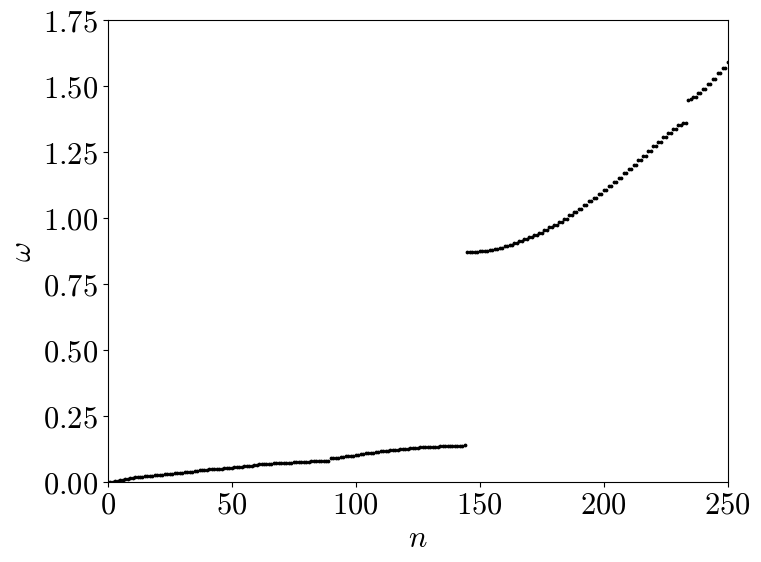

In [11]:
pl.figure(figsize=[8,6])
pl.ylim(0,1.75)
pl.xlim(0,250)
pl.xlabel('$n$')
pl.ylabel(r'$\omega$')
pl.scatter(np.arange(-4999,4999),sorted(valuesa),color='black',s=3)

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_132144/3343262801.py:6: SyntaxWarning: invalid escape sequence '\p'
  pl.ylabel('$\psi$')


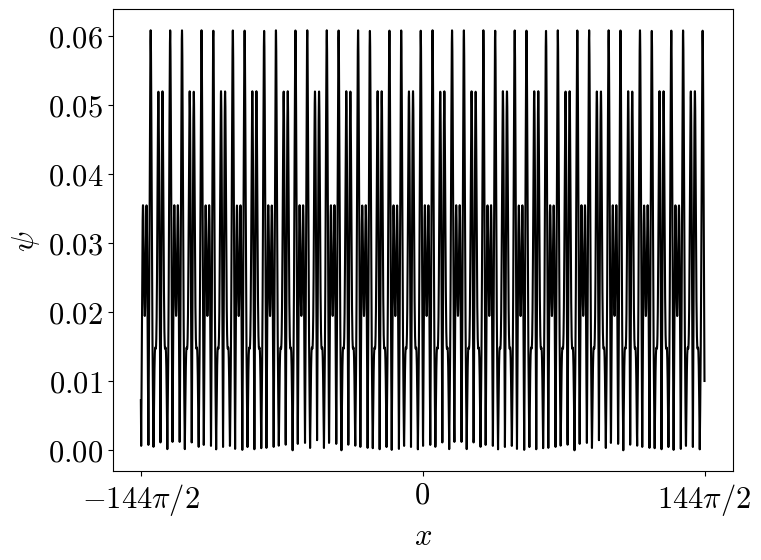

In [13]:
pl.figure(figsize=[8,6])
barras=(-144*np.pi/2,0,144*np.pi/2)
labels=(r'$-144\pi/2$','0',r'$144\pi/2$')
pl.xticks(barras,labels)
pl.xlabel('$x$')
pl.ylabel('$\psi$')
#pl.yscale('log')

pl.plot(xx,abs(estados3[:,2000]),color='black')

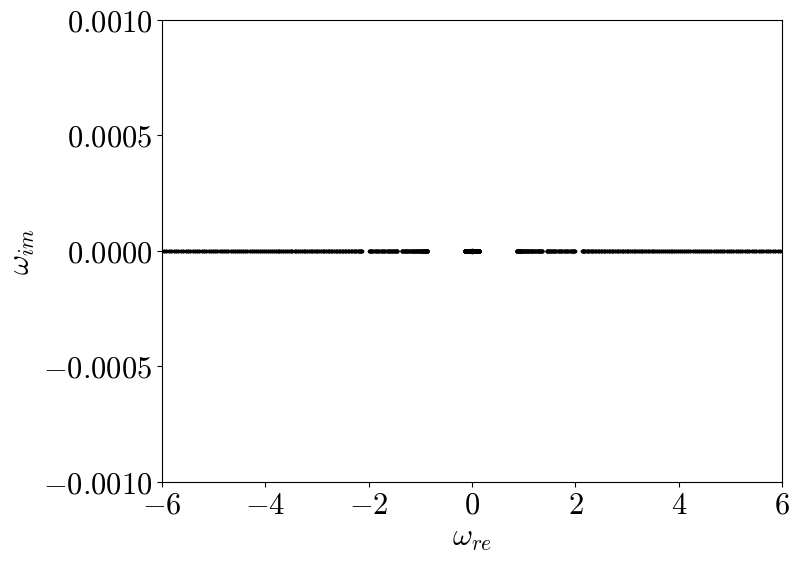

In [39]:
pl.figure(figsize=[8,6])
pl.xlim(-6,6)
pl.ylim(-0.001,0.001)
pl.xlabel(r'$\omega_{re}$')
pl.ylabel(r'$\omega_{im}$')
pl.scatter(valuesa.real,valuesa.imag,color='black',s=3)

In [5]:
#onda = np.loadtxt('perturbacao89',dtype=complex)
onda = np.loadtxt('perturbacao54',dtype=complex)

<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_5319/3175860915.py:21: SyntaxWarning: invalid escape sequence '\p'
  pl.ylabel('Density $|\psi(x,t)|^2$')


0 0.18131416306904177
10000 0.18131416306887493
20000 0.18131416306874187
30000 0.18131416306864184
40000 0.18131416306854425
50000 0.18131416306840734
60000 0.18131416306828838
70000 0.18131416306822384
80000 0.18131416306816378
90000 0.18131416306808026
100000 0.18131416306797077
110000 0.18131416306791454
120000 0.1813141630677942
130000 0.18131416306768489
140000 0.181314163067547
150000 0.18131416306741308
160000 0.18131416306733403
170000 0.18131416306732076
180000 0.18131416306720705
190000 0.18131416306712037
200000 0.18131416306706272
210000 0.18131416306698478
220000 0.18131416306679335
230000 0.1813141630666732
240000 0.18131416306659554
250000 0.18131416306645398
260000 0.18131416306635917
270000 0.18131416306628267
280000 0.1813141630661513
290000 0.1813141630660713
300000 0.1813141630660097
310000 0.1813141630659322
320000 0.1813141630658172
330000 0.1813141630657114
340000 0.181314163065607
350000 0.18131416306548198
360000 0.18131416306539389
370000 0.18131416306528353


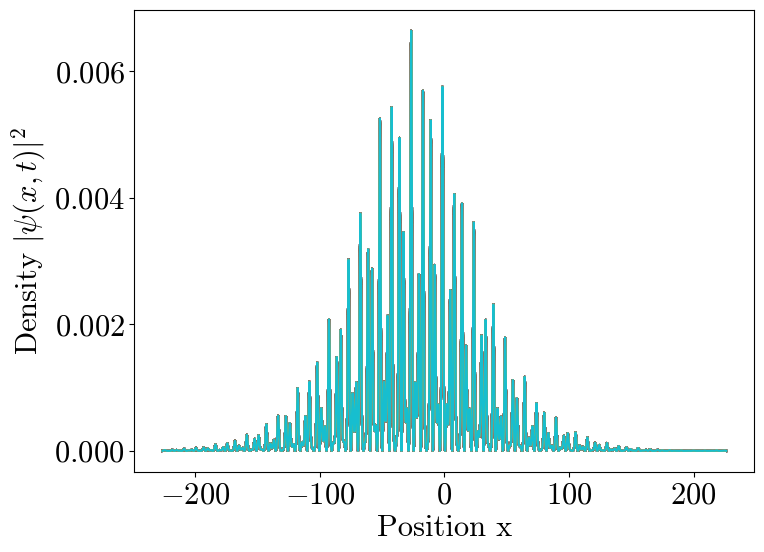

In [7]:
#onda = vectorsa[0:nx,indice]
T = 500
nt = 1000000

# Time evolution loop
psi = estados3[:,2000]

psi_list = []
for j in range(nt):
    psi,const0 = evolucao(T,nt,nx,M,N,v1,v2,phi,psi)
    if j % 10000 == 0:  # Save some frames for visualization
        print(j,const0)
        psi_list.append(np.abs(psi)**2)

# Visualization: Plot the density of the wave function at different times
pl.figure(figsize=(8,6))
for i, psi_t in enumerate(psi_list):
    pl.plot(xx, psi_t)
    
pl.xlabel('Position x')
pl.ylabel('Density $|\psi(x,t)|^2$')
#pl.legend()
pl.show()

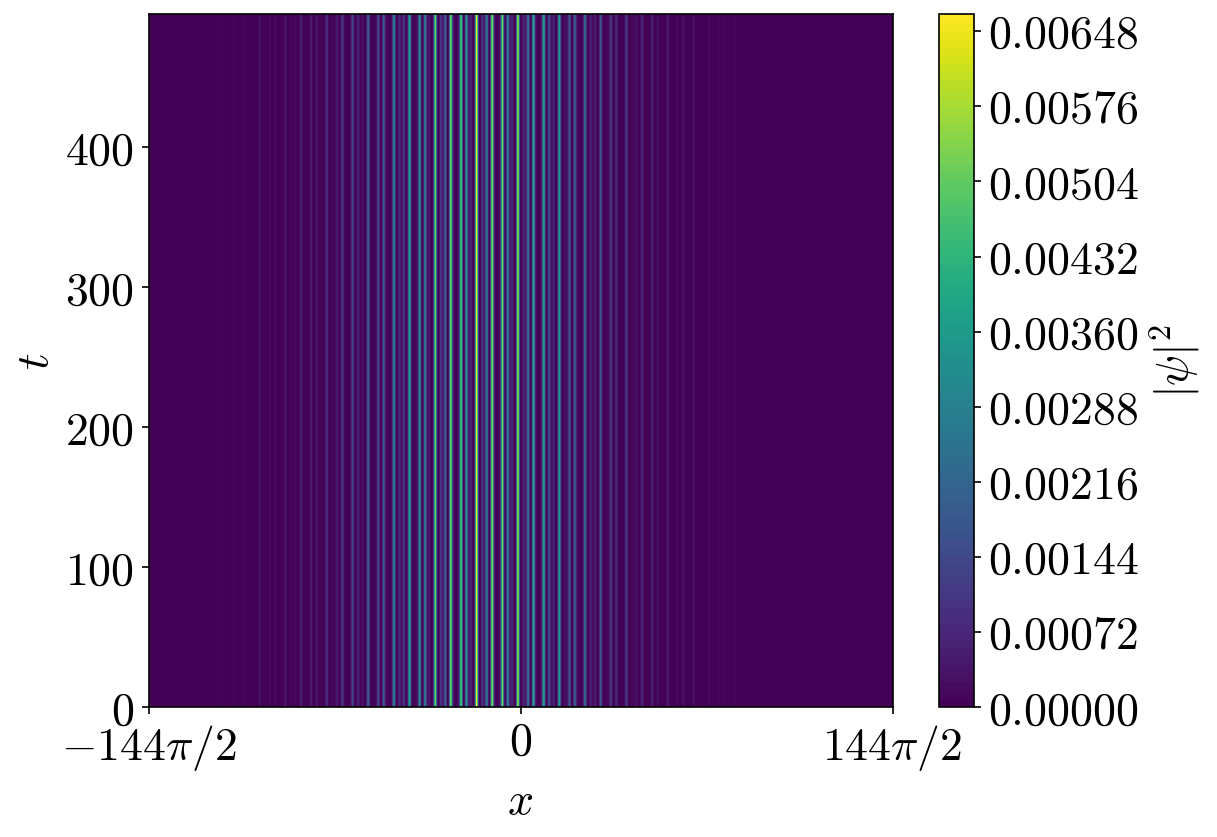

In [8]:
t = np.linspace(0,T,nt)
x,y = np.meshgrid(xx,t[::10000])
barras=(-144*np.pi/2,0,144*np.pi/2)
labels=(r'$-144\pi/2$','0',r'$144\pi/2$')



pl.rcParams['font.size'] = 22

pl.figure(figsize=[8,6],dpi=150)
pl.contourf(x,y,psi_list,levels=100)
pl.xlabel('$x$')
pl.ylabel('$t$')
pl.xticks(barras,labels)
cbar = pl.colorbar()
cbar.set_label(r'$|\psi|^2$')

In [8]:
np.savetxt('instavelatr54',psi_list)

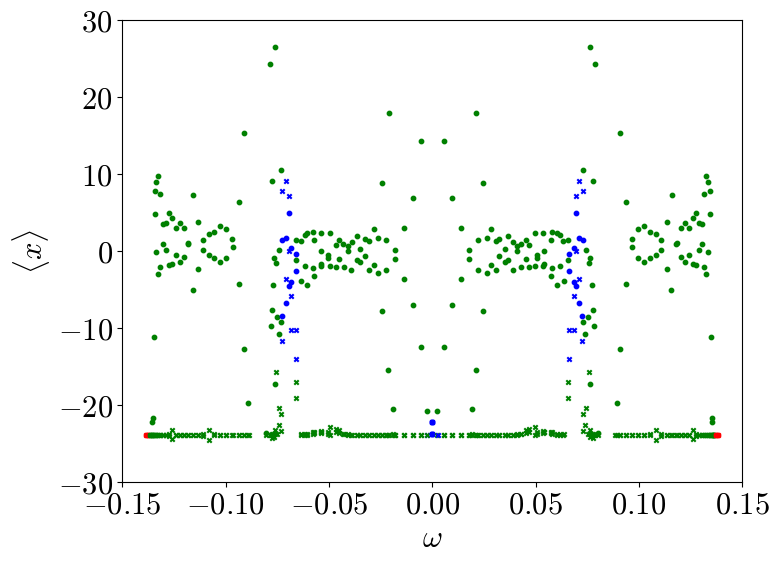

In [30]:
nx = 5000

pl.rcParams['font.size'] = 22
pl.figure(figsize=[8,6],dpi=100)
pl.xlabel(r'$\omega$')
pl.ylabel(r'$\langle x \rangle$')
pl.xlim(-0.15,0.15)
pl.ylim(-30,30)
indice = 4500
for i,j in enumerate(sorted(valuesa.real)[4500:5500]):
    nivel = np.ravel(np.where(valuesa==(sorted(valuesa)[indice])))
    u = vectorsa[0:nx,nivel[0]]
    v = vectorsa[nx:,nivel[0]]
    psiu = u.real**2+u.imag**2
    psiv = v.real**2+v.imag**2
    natomsu = (ht/3) * (psiu[0] + 2*sum(psiu[:nx-2:2]) + 4*sum(psiu[1:nx-1:2]) + psiu[nx-1])
    natomsv = (ht/3) * (psiv[0] + 2*sum(psiv[:nx-2:2]) + 4*sum(psiv[1:nx-1:2]) + psiv[nx-1])
 
    centrou = xx*psiu
    centrov = xx*psiv
    centrosu = (1/natomsu)*(ht/3)*(centrou[0] + 2*sum(centrou[:nx-2:2]) + 4*sum(centrou[1:nx-1:2]) + centrou[nx-1])
    centrosv = (1/natomsv)*(ht/3)*(centrov[0] + 2*sum(centrov[:nx-2:2]) + 4*sum(centrov[1:nx-1:2]) + centrov[nx-1])
    if indice in localizados:
        pl.scatter(j,centrosu,color='red',s=10)
        pl.scatter(j,centrosv,color='red',s=10,marker='x')
    elif indice in ulocalizado:
        pl.scatter(j,centrosu,color='green',s=10)
        pl.scatter(j,centrosv,color='green',s=10,marker='x')
    elif indice in vlocalizado:
        pl.scatter(j,centrosu,color='green',s=10)
        pl.scatter(j,centrosv,color='green',s=10,marker='x')
    elif indice in deslocalizados:
        pl.scatter(j,centrosu,color='blue',s=10)
        pl.scatter(j,centrosv,color='blue',s=10,marker='x')
    indice+=1

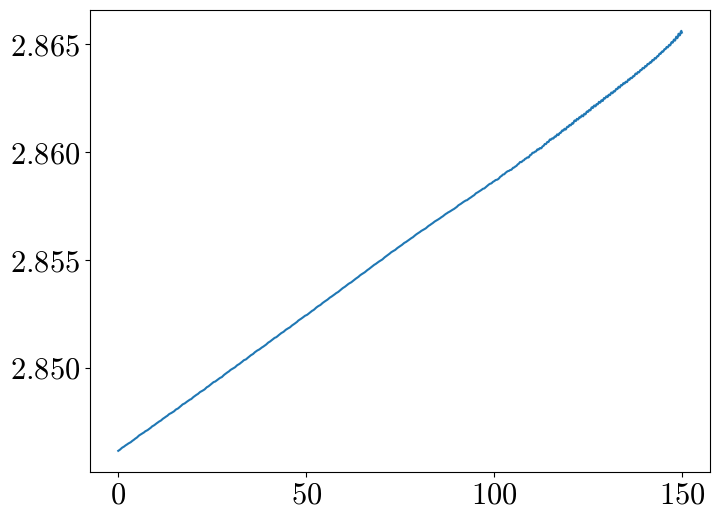

In [11]:
pl.figure(figsize=[8,6])
pl.plot(t[::100],modulos[::100])

In [148]:
print(sorted(vlinear3)[87],sorted(vlinear3)[88],sorted(vlinear3)[89],sorted(vlinear3)[90])

(-0.03540208236725571+0j) (-0.035402082367233904+0j) (-0.014968114842890418+0j) (-0.014968114842887736+0j)


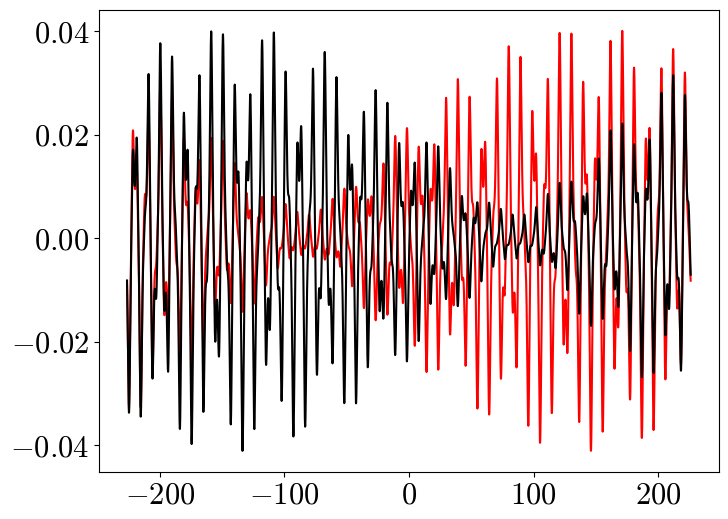

In [147]:
indice1 = np.ravel(np.where(vlinear3 == sorted(vlinear3)[89]))[0]
indice2 = np.ravel(np.where(vlinear3 == sorted(vlinear3)[90]))[0]
 


pl.figure(figsize=[8,6])
pl.plot(xx,psilinear3[:,indice1],color='red')
pl.plot(xx,psilinear3[:,indice2],color='black')

<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_90757/2082033590.py:24: SyntaxWarning: invalid escape sequence '\c'
  pl.ylabel('$\chi$')
/usr/lib/python3/dist-packages/matplotlib/collections.py:193: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


4856
5143


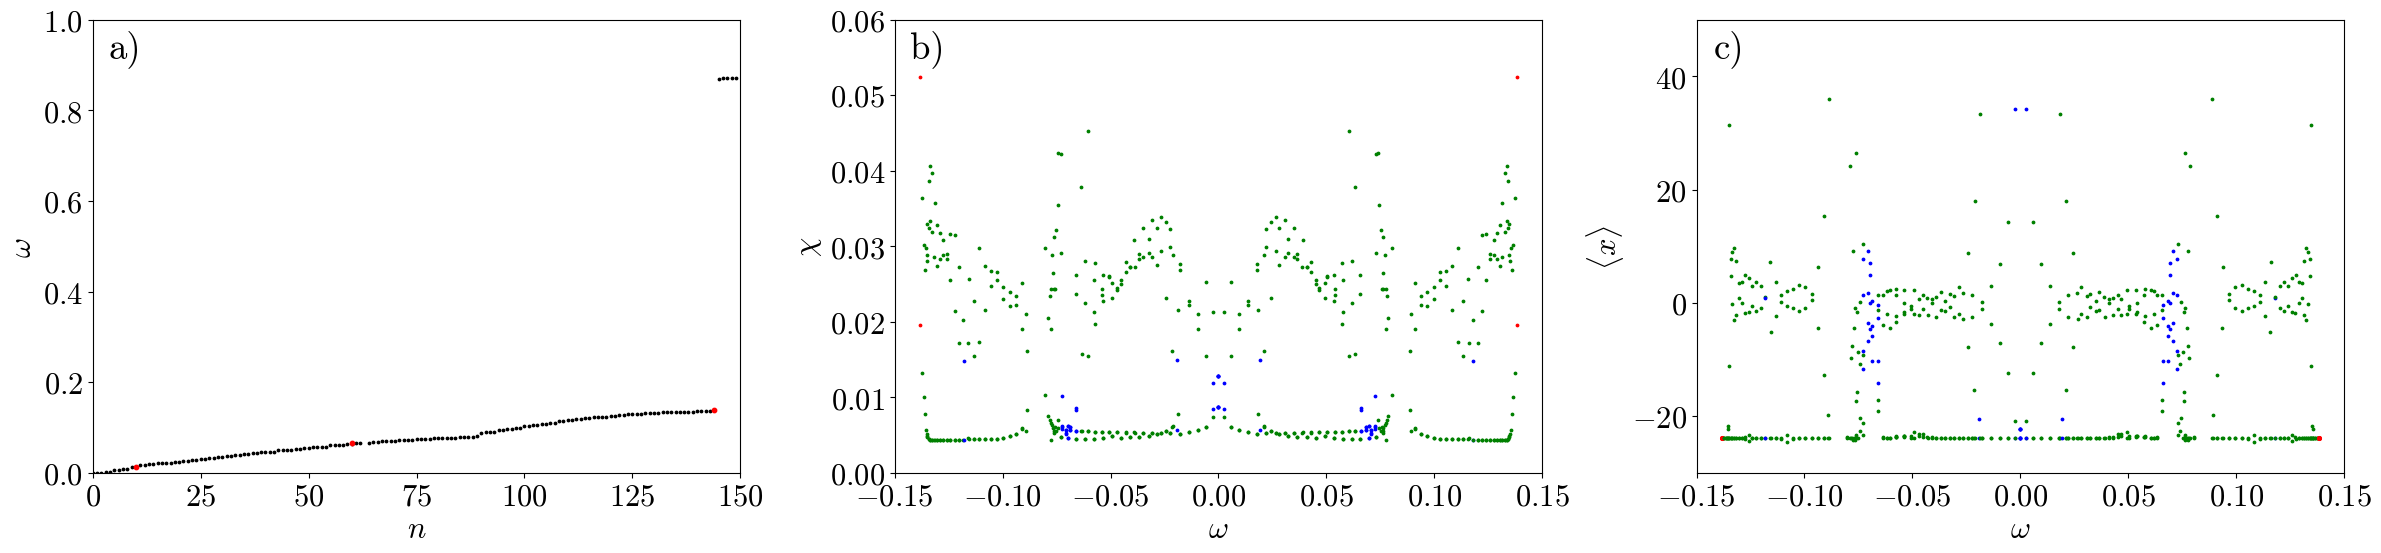

In [7]:
pl.figure(figsize=[24,6])
pl.subplot(1,3,1)

pl.title("a)", x=0.05, y=0.9)
pl.ylim(0,1)
pl.xlim(0,150)
pl.xlabel('$n$')
pl.ylabel(r'$\omega$')
pl.scatter(np.arange(0,10),sorted(valuesa)[4999:5009],color='black',s=3)
pl.scatter(np.arange(11,63),sorted(valuesa)[5010:5062],color='black',s=3)
pl.scatter(np.arange(64,144),sorted(valuesa)[5063:5143],color='black',s=3)
pl.scatter(np.arange(145,150),sorted(valuesa)[5144:5149],color='black',s=3)
pl.scatter(10,sorted(valuesa)[5009],color='red',s=10)
pl.scatter(60,sorted(valuesa)[5062],color='red',s=10)
pl.scatter(144,sorted(valuesa)[5143],color='red',s=10)


pl.subplot(1,3,2)

pl.title("b)", x=0.05, y=0.9)
pl.ylim(0,0.06)
pl.xlim(-0.15,0.15)
pl.xlabel(r'$\omega$')
pl.ylabel('$\chi$')

deslocalizados = []
ulocalizado = []
vlocalizado = []
localizados = []

for i in range(4500,5500):
    if participacaou[i] > 0.013:
        if participacaov[i] > 0.013:
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='red',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='red',s=3)
            print(i)
            localizados.append(i)
        elif normu[i] > 10**(-6):
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='green',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='green',s=3)
            ulocalizado.append(i)
    elif participacaov[i] > 0.013: 
        if normv[i] > 10**(-6):
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='green',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='green',s=3)
            vlocalizado.append(i)
    else:
        pl.scatter(sorted(valuesa)[i],participacaou[i],color='blue',s=3)
        pl.scatter(sorted(valuesa)[i],participacaov[i],color='blue',s=3)
        deslocalizados.append(i)
        
pl.subplot(1,3,3)

pl.title("c)", x=0.05, y=0.9)
pl.xlabel(r'$\omega$')
pl.ylabel(r'$\langle x \rangle$')
pl.xlim(-0.15,0.15)
pl.ylim(-30,50)
indice = 4750
for i,j in enumerate(sorted(valuesa.real)[4750:5250]):
    nivel = np.ravel(np.where(valuesa==(sorted(valuesa)[indice])))
    u = vectorsa[0:nx,nivel[0]]
    v = vectorsa[nx:,nivel[0]]
    psiu = u.real**2+u.imag**2
    psiv = v.real**2+v.imag**2
    natomsu = (ht/3) * (psiu[0] + 2*sum(psiu[:nx-2:2]) + 4*sum(psiu[1:nx-1:2]) + psiu[nx-1])
    natomsv = (ht/3) * (psiv[0] + 2*sum(psiv[:nx-2:2]) + 4*sum(psiv[1:nx-1:2]) + psiv[nx-1])
    centrou = xx*psiu
    centrov = xx*psiv
    centrosu = (1/natomsu)*(ht/3)*(centrou[0] + 2*sum(centrou[:nx-2:2]) + 4*sum(centrou[1:nx-1:2]) + centrou[nx-1])
    centrosv = (1/natomsv)*(ht/3)*(centrov[0] + 2*sum(centrov[:nx-2:2]) + 4*sum(centrov[1:nx-1:2]) + centrov[nx-1])
    if indice in localizados:
        pl.scatter(j,centrosu,color='red',s=7)
        pl.scatter(j,centrosv,color='red',s=7)
    elif indice in ulocalizado:
        pl.scatter(j,centrosu,color='green',s=3)
        pl.scatter(j,centrosv,color='green',s=3)
    elif indice in vlocalizado:
        pl.scatter(j,centrosu,color='green',s=3)
        pl.scatter(j,centrosv,color='green',s=3)
    elif indice in deslocalizados:
        pl.scatter(j,centrosu,color='blue',s=3)
        pl.scatter(j,centrosv,color='blue',s=3)
    indice+=1
    
pl.tight_layout()

In [21]:
valuesa2 = np.loadtxt('bdgatr89est',dtype=complex)
valuesa3 = np.loadtxt('bdgrep89est',dtype=complex)

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_31441/935718907.py:4: SyntaxWarning: invalid escape sequence '\o'
  pl.xlabel('$\omega_{re}$')
/tmp/ipykernel_31441/935718907.py:5: SyntaxWarning: invalid escape sequence '\o'
  pl.ylabel('$\omega_{im}$')
/tmp/ipykernel_31441/935718907.py:12: SyntaxWarning: invalid escape sequence '\o'
  pl.xlabel('$\omega_{re}$')
/tmp/ipykernel_31441/935718907.py:13: SyntaxWarning: invalid 

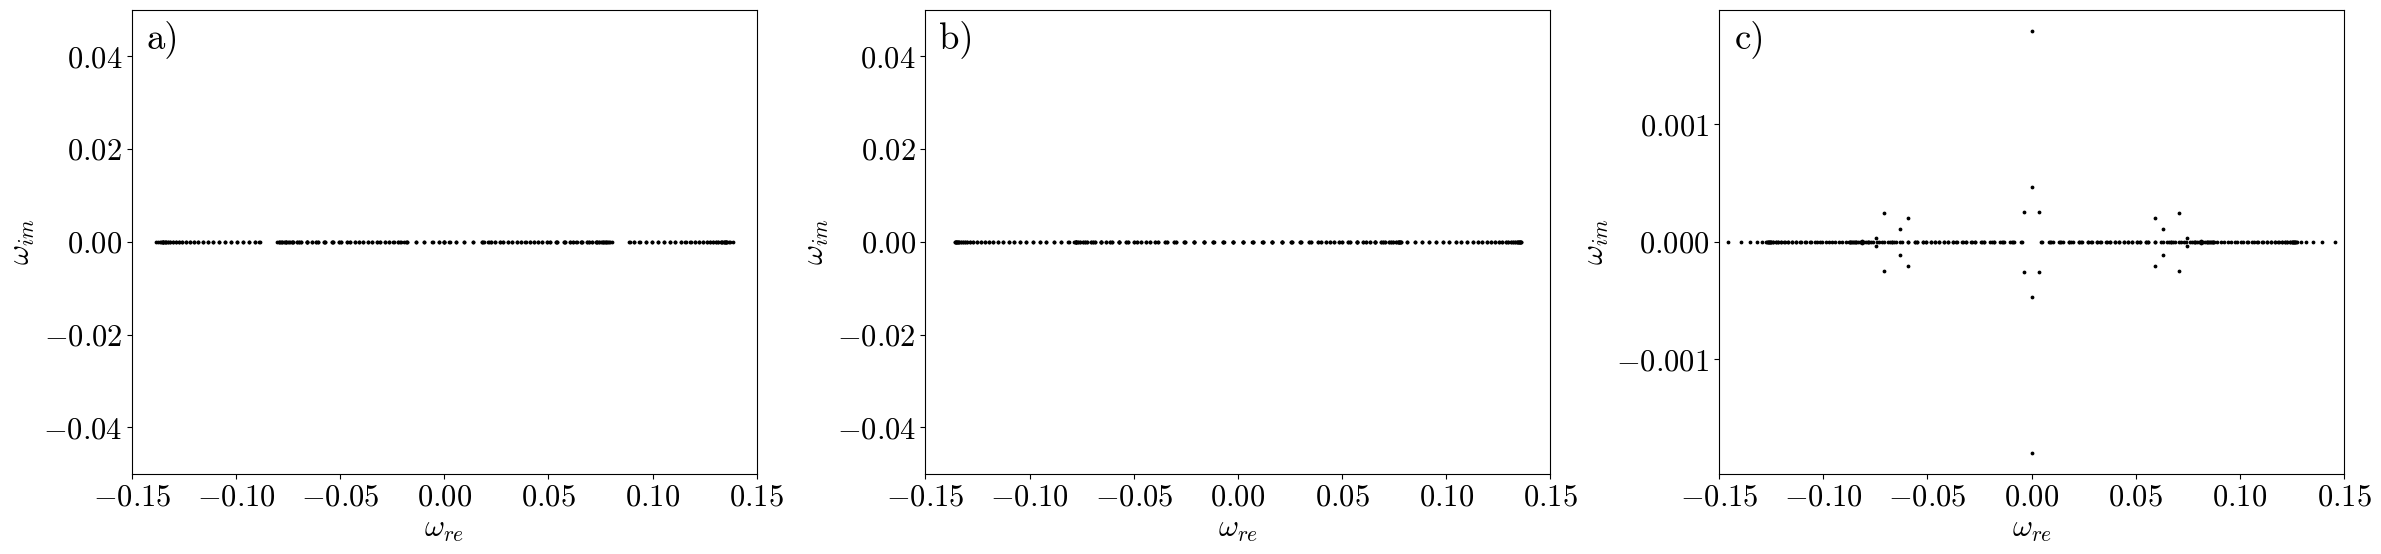

In [24]:
pl.figure(figsize=[24,6])
pl.subplot(1,3,1)
pl.title("a)", x=0.05, y=0.9)
pl.xlabel('$\omega_{re}$')
pl.ylabel('$\omega_{im}$')
pl.xlim(-0.15,0.15)
pl.ylim(-0.05,0.05)
pl.scatter(valuesa2.real,valuesa2.imag,color='black',s=3)

pl.subplot(1,3,2)
pl.title("b)", x=0.05, y=0.9)
pl.xlabel('$\omega_{re}$')
pl.ylabel('$\omega_{im}$')
pl.xlim(-0.15,0.15)
pl.ylim(-0.05,0.05)
pl.scatter(valuesa3.real,valuesa3.imag,color='black',s=3)

pl.subplot(1,3,3)
pl.title("c)", x=0.05, y=0.9)
pl.xlabel('$\omega_{re}$')
pl.ylabel('$\omega_{im}$')
pl.xlim(-0.15,0.15)
pl.scatter(valuesa.real,valuesa.imag,color='black',s=3)
pl.tight_layout()

<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:35: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_39202/121917514.py:35: SyntaxWarning: invalid escape sequence '\c'
  subfigs[1,0].set_xlabel('$\chi$')


4856
4857
5142
5143


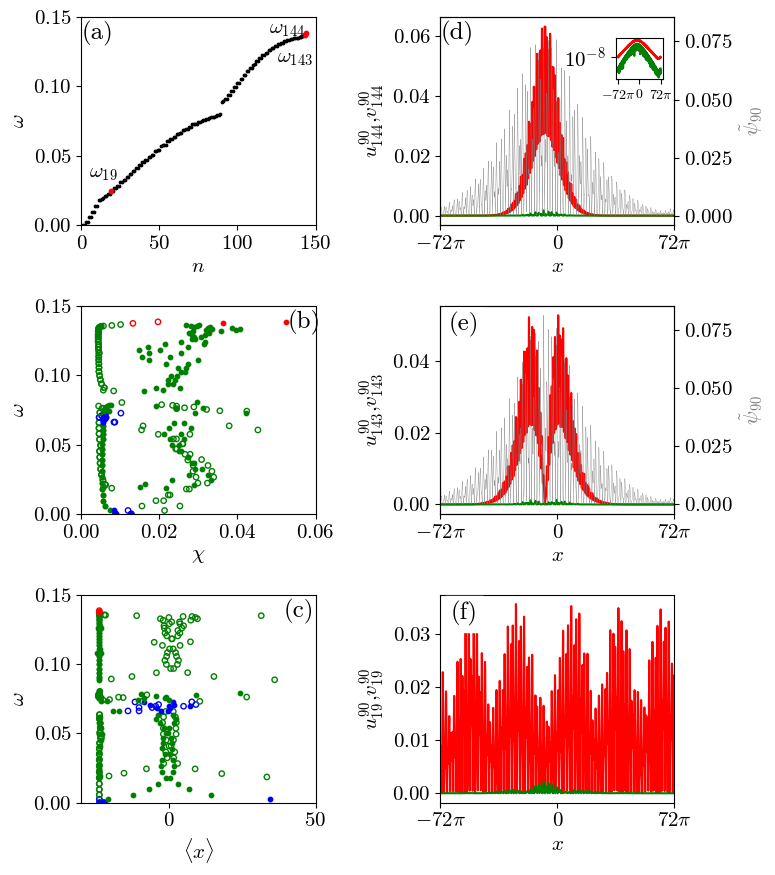

In [26]:
pl.rcParams['font.size'] = 15

indice1 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4856]))[0]
indice2 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4857]))[0]
indice3 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[5018]))[0]
barras=(-72*np.pi,0,72*np.pi)
labels=(r'$-72\pi$','0',r'$72\pi$')


fig = pl.figure(figsize=[8,9])

subfigs = fig.subplots(3,2)
subfigs[0,0].set_title("(a)",x=0.07,y=0.85)
subfigs[0,0].set_ylim(0,0.15)
subfigs[0,0].set_xlim(0,150)
subfigs[0,0].set_xlabel('$n$')
subfigs[0,0].set_ylabel(r'$\omega$')
subfigs[0,0].scatter(np.arange(1,19),sorted(valuesa)[5000:5018],color='black',s=3)
subfigs[0,0].scatter(np.arange(20,143),sorted(valuesa)[5019:5142],color='black',s=3)
subfigs[0,0].scatter(np.arange(145,150),sorted(valuesa)[5144:5149],color='black',s=3)
subfigs[0,0].scatter(19,sorted(valuesa)[5018],color='red',s=10)
subfigs[0,0].scatter(143,sorted(valuesa)[5142],color='red',s=10)
subfigs[0,0].scatter(144,sorted(valuesa)[5143],color='red',s=10)

subfigs[0,0].text(5,sorted(valuesa)[5018]+0.01,r'$\omega_{19}$',fontsize=15)
subfigs[0,0].text(125,sorted(valuesa)[5142]-0.02,r'$\omega_{143}$',fontsize=15)
subfigs[0,0].text(120,sorted(valuesa)[5143],r'$\omega_{144}$',fontsize=15)



subfigs[1,0].set_title("(b)", x=0.95, y=0.85)
subfigs[1,0].set_xlim(0,0.06)
subfigs[1,0].set_ylim(0,0.15)
subfigs[1,0].set_ylabel(r'$\omega$')
subfigs[1,0].set_xlabel('$\chi$')

deslocalizados = []
ulocalizado = []
vlocalizado = []
localizados = []

for i in range(4500,5500):
    if participacaou[i] > 0.013:
        if participacaov[i] > 0.013:
            subfigs[1,0].scatter(participacaou[i],sorted(valuesa)[i],color='red',s=10)
            subfigs[1,0].scatter(participacaov[i],sorted(valuesa)[i],color='red',s=15,edgecolors='red',facecolors='none')
            print(i)
            localizados.append(i)
        elif normu[i] > 10**(-6):
            subfigs[1,0].scatter(participacaou[i],sorted(valuesa)[i],color='green',s=10)
            subfigs[1,0].scatter(participacaov[i],sorted(valuesa)[i],color='green',s=15,edgecolors='green',facecolors='none')
            ulocalizado.append(i)
    elif participacaov[i] > 0.013: 
        if normv[i] > 10**(-6):
            subfigs[1,0].scatter(participacaou[i],sorted(valuesa)[i],color='green',s=10)
            subfigs[1,0].scatter(participacaov[i],sorted(valuesa)[i],color='green',s=15,edgecolors='green',facecolors='none')
            vlocalizado.append(i)
    else:
        subfigs[1,0].scatter(participacaou[i],sorted(valuesa)[i],color='blue',s=10)
        subfigs[1,0].scatter(participacaov[i],sorted(valuesa)[i],color='blue',s=15,edgecolors='blue',facecolors='none')
        deslocalizados.append(i)
        

subfigs[2,0].set_title("(c)", x=0.93, y=0.85)
subfigs[2,0].set_ylabel(r'$\omega$')
subfigs[2,0].set_xlabel(r'$\langle x \rangle$')
subfigs[2,0].set_ylim(0,0.15)
subfigs[2,0].set_xlim(-30,50)
indice = 4750
for i,j in enumerate(sorted(valuesa.real)[4750:5250]):
    nivel = np.ravel(np.where(valuesa==(sorted(valuesa)[indice])))
    u = vectorsa[0:nx,nivel[0]]
    v = vectorsa[nx:,nivel[0]]
    psiu = u.real**2+u.imag**2
    psiv = v.real**2+v.imag**2
    natomsu = (ht/3) * (psiu[0] + 2*sum(psiu[:nx-2:2]) + 4*sum(psiu[1:nx-1:2]) + psiu[nx-1])
    natomsv = (ht/3) * (psiv[0] + 2*sum(psiv[:nx-2:2]) + 4*sum(psiv[1:nx-1:2]) + psiv[nx-1])

    centrou = xx*psiu
    centrov = xx*psiv
    centrosu = (1/natomsu)*(ht/3)*(centrou[0] + 2*sum(centrou[:nx-2:2]) + 4*sum(centrou[1:nx-1:2]) + centrou[nx-1])
    centrosv = (1/natomsv)*(ht/3)*(centrov[0] + 2*sum(centrov[:nx-2:2]) + 4*sum(centrov[1:nx-1:2]) + centrov[nx-1])
    if indice in localizados:
        subfigs[2,0].scatter(centrosu,j,color='red',s=10)
        subfigs[2,0].scatter(centrosv,j,color='red',s=15,edgecolors='red',facecolors='none')
    elif indice in ulocalizado:
        subfigs[2,0].scatter(centrosu,j,color='green',s=10)
        subfigs[2,0].scatter(centrosv,j,color='green',s=15,edgecolors='green',facecolors='none')
    elif indice in vlocalizado:
        subfigs[2,0].scatter(centrosu,j,color='green',s=10)
        subfigs[2,0].scatter(centrosv,j,color='green',s=15,edgecolors='green',facecolors='none')
    elif indice in deslocalizados:
        subfigs[2,0].scatter(centrosu,j,color='blue',s=10)
        subfigs[2,0].scatter(centrosv,j,color='blue',s=15,edgecolors='blue',facecolors='none')
    indice+=1
    

subfigs[0,1].set_title("(d)", x=0.07, y=0.85)
inset = subfigs[0,1].inset_axes([0.75, 0.7, 0.2, 0.2])
subfigs[0,1].set_xlabel('$x$')
subfigs[0,1].set_ylabel('$u^{90}_{144}$,$v^{90}_{144}$')
subfigs[0,1].set_xticks(barras,labels)
subfigs[0,1].set_xlim(-72*np.pi,72*np.pi)

othery = subfigs[0,1].twinx()
othery.set_ylabel(r'$\tilde{\psi}_{90}$',color='gray')
othery.plot(xx,abs(estados3[:,2000]),color='gray',linewidth=0.25)
othery.tick_params(axis='y')

#subfigs[0,1].plot(xx,abs(estados3[:,2000]),color='black',linewidth=0.5)
subfigs[0,1].plot(xx,abs(vectorsa[0:nx,indice1]),color='red')
subfigs[0,1].plot(xx,abs(vectorsa[nx:,indice1]),color='green')

inset.set_xticks(barras,labels,fontsize=10)
inset.set_yscale('log')

inset.plot(xx,abs(vectorsa[0:nx,indice1]),color='red')
inset.plot(xx,abs(vectorsa[nx:,indice1]),color='green')

subfigs[1,1].set_title("(e)", x=0.1, y=0.84,backgroundcolor='white')
subfigs[1,1].set_xlabel('$x$')
subfigs[1,1].set_ylabel('$u^{90}_{143}$,$v^{90}_{143}$')
subfigs[1,1].set_xticks(barras,labels)
subfigs[1,1].set_xlim(-72*np.pi,72*np.pi)

othery = subfigs[1,1].twinx()
othery.set_ylabel(r'$\tilde{\psi}_{90}$',color='gray')
othery.plot(xx,abs(estados3[:,2000]),color='gray',linewidth=0.25)
othery.tick_params(axis='y')

#subfigs[1,1].plot(xx,abs(estados3[:,2000]),color='black',linewidth=0.5)
subfigs[1,1].plot(xx,abs(vectorsa[0:nx,indice2]),color='red')
subfigs[1,1].plot(xx,abs(vectorsa[nx:,indice2]),color='green')

subfigs[2,1].set_title("(f)", x=0.1, y=0.84,backgroundcolor='white')
subfigs[2,1].set_xlabel('$x$')
subfigs[2,1].set_ylabel('$u^{90}_{19}$,$v^{90}_{19}$')
subfigs[2,1].set_xticks(barras,labels)
subfigs[2,1].set_xlim(-72*np.pi,72*np.pi)

subfigs[2,1].plot(xx,abs(vectorsa[nx:,indice3]),color='red')
subfigs[2,1].plot(xx,abs(vectorsa[0:nx,indice3]),color='green')

pl.tight_layout()
pl.show()

In [25]:
print(ulocalizado)

[4914, 4915, 4917, 4918, 4919, 4922, 4923, 4924, 4925, 4940, 4941, 4944, 4945, 4948, 4949, 4950, 4951, 4954, 4955, 4958, 4959, 4962, 4963, 4966, 4967, 4970, 4971, 4974, 4975, 4978, 4979, 4982, 4983, 4988, 4989, 4990, 4991, 4992, 4993, 4994, 4995, 4997, 5012, 5013, 5014, 5015, 5018, 5019, 5022, 5023, 5026, 5027, 5030, 5031, 5034, 5035, 5038, 5039, 5042, 5043, 5046, 5047, 5052, 5053, 5056, 5057, 5060, 5061, 5072, 5073, 5078, 5079, 5083, 5088, 5089, 5090, 5091, 5092, 5093, 5094, 5095, 5096, 5097, 5098, 5099, 5100, 5101, 5102, 5103, 5104, 5105, 5106, 5107, 5108, 5109, 5110, 5111, 5112, 5113, 5114, 5115, 5116, 5117, 5118, 5119, 5120, 5121, 5122, 5123, 5124, 5125, 5126, 5127, 5128, 5129, 5130, 5131, 5132, 5133, 5134, 5135, 5136, 5138, 5139, 5140, 5141]


In [9]:
np.savetxt('fonaoloc',vectorsa[:,indice1])
np.savetxt('fonaouloc',vectorsa[:,indice2])
np.savetxt('fonaodesloc',vectorsa[:,indice2])

In [25]:
print(sorted(valuesa)[247],sorted(valuesa)[248],sorted(valuesa)[249],sorted(valuesa)[250],sorted(valuesa)[251],sorted(valuesa)[252])

(-0.004678560351290054+0j) (-1.0830421533984047e-16-4.530740665674165e-09j) (-1.0830421533984047e-16+4.530740665674165e-09j) (4.084696338507401e-17-6.18858315172515e-08j) (4.084696338507401e-17+6.18858315172515e-08j) (0.004678065649371889+0j)


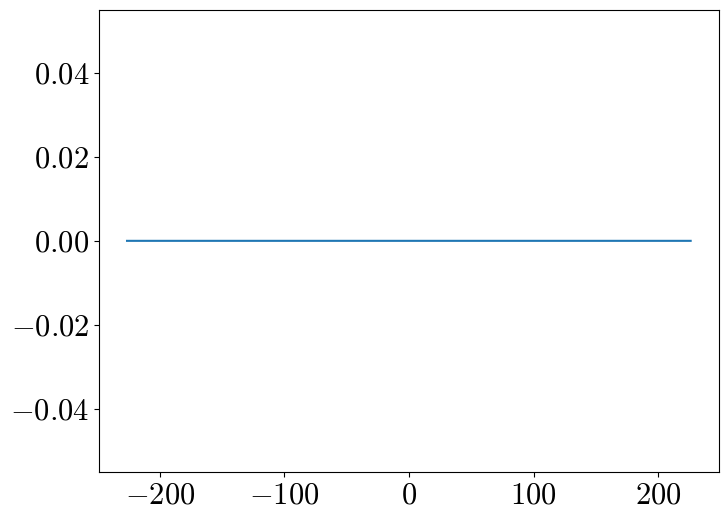

In [5]:
xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
hx = xx[1]-xx[0]

potential = V(xx[:-1],v1,v2,M,N,phi)

diagonal1 = -1/(2*hx**2)*np.ones(nx-1)
fronteira = -1/(2*hx**2)
    
diagonal = -potenciais3[2000]+potential+3*g*estados3[:,2000]**2+1/hx**2
diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira]
        
J = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr')
        
upsi = sp.sparse.linalg.spsolve(J,np.zeros(nx))

pl.figure(figsize=[8,6])
pl.plot(xx[:-1],upsi)

In [14]:
print(sorted(valuesa)[247],sorted(valuesa)[248],sorted(valuesa)[249],sorted(valuesa)[250],sorted(valuesa)[251])

(-1.6827864173730078e-11-3.7679003151242957e-06j) (-1.6827864173730078e-11+3.7679003151242957e-06j) (-4.227979061462417e-17-6.214818713155264e-09j) (-4.227979061462417e-17+6.214818713155264e-09j) (0.0025070972673066657+0j)
